# Отток клиентов (Telco Churn) — исправленная версия

Это переработанный вариант ноутбука. Перед каждой ячейкой — короткое
объяснение, что она делает и зачем. По ходу отмечены места, где были
баги/утечки данных в исходной версии и как они исправлены здесь.

**Ключевые изменения по сравнению с прошлой версией:**
- сплит на train / val / test делается **до** feature engineering (иначе
  статистики вроде квантиля считаются с подглядыванием в тест);
- подбор гиперпараметров, порога классификации и бизнес-порога — всё
  происходит на `val`, а `test` используется **один раз**, в самом конце;
- `ServiceCount` больше не занижен (баг с `InternetService`, у которого
  нет значения `"Yes"`, исправлен);
- baseline-модель (LogisticRegression) обучается на тех же признаках,
  что и CatBoost — раньше препроцессор для неё был собран до того, как
  фичи были готовы, и часть новых признаков в неё просто не попадала.

## 1. Импорты

Ничего необычного — стандартный стек для классификации плюс CatBoost.
`class_weight`/`compute_class_weight` понадобятся, чтобы модель не
игнорировала класс "Churn" (его в 2.7 раза меньше, чем "No Churn").

In [2]:
!pip install catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 19.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

## 2. Загрузка и базовая чистка

- `customerID` — идентификатор, не признак, убираем сразу.
- `TotalCharges` загружается как строка: у 11 клиентов с `tenure=0`
  там пустая строка вместо числа (они ещё не платили). Переводим в
  число, пропуски заполняем нулём.
- Таргет `Churn` (`Yes`/`No`) переводим в `1`/`0`.

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["Churn"])

print(df.shape)
df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Train / Val / Test — СРАЗУ, до feature engineering

Раньше признаки (квантили, флаги и т.д.) считались по всему датасету,
а сплит делался позже — это утечка: тестовые данные влияли на то, как
строится обучающая фича. Здесь делаем наоборот:

1. Сначала делим на train/val/test.
2. Все статистики (квантили и т.п.) для feature engineering считаем
   **только по train**, а к val/test применяем уже готовые пороги.

`val` (валидация) нужен для подбора гиперпараметров и порога
классификации. `test` не участвует нигде, кроме одной финальной
оценки в конце ноутбука — так метрика на нём честно отражает качество
на новых данных.

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

train: (4507, 19) val: (1127, 19) test: (1409, 19)


## 4. Feature engineering

Те же признаки, что были в исходной версии, но с двумя исправлениями:

1. **`ServiceCount` считался неверно.** Для `OnlineSecurity`,
   `TechSupport` и т.п. значения `Yes`/`No`/`No internet service` —
   сравнение `== 'Yes'` работает корректно. А вот у `InternetService`
   значения `DSL` / `Fiber optic` / `No` — значения `'Yes'` там нет
   вообще, и старый код давал 0 для абсолютно всех клиентов с
   интернетом. Здесь для `InternetService` считаем отдельно: `!= 'No'`.
2. **Квантиль `MonthlyCharges` считается по `X_train`**, а не по всему
   `X` — иначе это утечка теста в признак.

Функция `add_features` принимает уже посчитанный на train квантиль
как параметр и одинаково применяется к train/val/test.

In [6]:
q75_monthly = X_train["MonthlyCharges"].quantile(0.75)

def add_features(df_part, q75_monthly_ref):
    df_part = df_part.copy()

    # Средний чек за всё время
    df_part['AvgMonthlyCharge'] = df_part['TotalCharges'] / (df_part['tenure'] + 1)

    # Количество подключённых услуг
    service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    tmp_cols = []
    for col in service_cols:
        tmp = col + '_num'
        df_part[tmp] = (df_part[col] == 'Yes').astype(int)
        tmp_cols.append(tmp)

    # InternetService — отдельно: значения DSL/Fiber optic/No, а не Yes/No
    df_part['InternetService_num'] = (df_part['InternetService'] != 'No').astype(int)
    tmp_cols.append('InternetService_num')

    df_part['ServiceCount'] = df_part[tmp_cols].sum(axis=1)
    df_part = df_part.drop(columns=tmp_cols)

    # Сегментация клиентов
    df_part['IsNewCustomer'] = (df_part['tenure'] <= 6).astype(int)
    df_part['IsLongTerm'] = (df_part['tenure'] >= 48).astype(int)
    df_part['HighMonthlyLowTenure'] = (
        (df_part['MonthlyCharges'] > q75_monthly_ref) & (df_part['tenure'] < 12)
    ).astype(int)

    # Ценовые фичи
    df_part['MonthlyToTotalRatio'] = df_part['MonthlyCharges'] / (df_part['TotalCharges'] + 1)
    df_part['ExpectedTotal'] = df_part['MonthlyCharges'] * df_part['tenure']
    df_part['TotalDiff'] = df_part['TotalCharges'] - df_part['ExpectedTotal']

    # Контракт = риск
    df_part['IsMonthToMonth'] = (df_part['Contract'] == 'Month-to-month').astype(int)
    return df_part

X_train_fe = add_features(X_train, q75_monthly)
X_val_fe = add_features(X_val, q75_monthly)
X_test_fe = add_features(X_test, q75_monthly)

X_train_fe.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,AvgMonthlyCharge,ServiceCount,IsNewCustomer,IsLongTerm,HighMonthlyLowTenure,MonthlyToTotalRatio,ExpectedTotal,TotalDiff,IsMonthToMonth
6592,Male,0,No,No,26,Yes,No,DSL,No,No,...,1507.00,55.814815,4,0,0,0,0.039423,1545.70,-38.70,0
464,Male,1,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,8404.90,115.135616,9,0,1,0,0.013806,8355.60,49.30,0
5420,Male,0,Yes,No,70,Yes,Yes,Fiber optic,Yes,Yes,...,8244.30,116.116901,9,0,1,0,0.013862,8001.00,243.30,0
629,Male,1,Yes,No,49,Yes,Yes,Fiber optic,No,Yes,...,4547.25,90.945000,5,0,1,0,0.019799,4412.45,134.80,1
431,Female,0,Yes,Yes,72,No,No phone service,DSL,Yes,Yes,...,4784.45,65.540411,7,0,1,0,0.013625,4694.40,90.05,0


## 5. Списки числовых и категориальных признаков

Считаем один раз, сразу после feature engineering — и этот же список
пойдёт и в `ColumnTransformer` для LogisticRegression, и в `CatBoost`
(в отличие от прошлой версии, где препроцессор для LogReg был собран
раньше, чем появились новые фичи, и часть из них туда просто не
попадала).

In [7]:
num_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
                'AvgMonthlyCharge', 'ServiceCount', 'IsNewCustomer', 'IsLongTerm',
                'HighMonthlyLowTenure', 'MonthlyToTotalRatio', 'ExpectedTotal',
                'TotalDiff', 'IsMonthToMonth']
cat_features = [col for col in X_train_fe.columns if col not in num_features]

print(f"Числовых фичей: {len(num_features)}")
print(f"Категориальных фичей: {len(cat_features)}")
print(f"Всего: {X_train_fe.shape[1]}")

Числовых фичей: 13
Категориальных фичей: 15
Всего: 28


## 6. Веса классов

Классов "Churn" примерно в 2.7 раза меньше — без учёта этого модель
будет склоняться предсказывать "No Churn" почти всегда. Веса считаем
**по `y_train`**, а не по всему датасету — иначе информация про
распределение классов в val/test просочится в обучение.

In [8]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print(f"Веса классов: {class_weights}")

Веса классов: {np.int64(0): np.float64(0.6806100875868317), np.int64(1): np.float64(1.8841973244147157)}


## 7. Baseline: LogisticRegression

Собираем `ColumnTransformer` (масштабирование чисел + OneHot для
категорий) **после** того, как готовы финальные списки признаков —
чтобы модель реально их видела. Это честный baseline для сравнения с
CatBoost ниже.

In [9]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_features),
])

logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

logreg.fit(X_train_fe, y_train)
logreg_proba_val = logreg.predict_proba(X_val_fe)[:, 1]
print(f"LogReg baseline, ROC-AUC (val): {roc_auc_score(y_val, logreg_proba_val):.4f}")

LogReg baseline, ROC-AUC (val): 0.8533


## 8. CatBoost

CatBoost умеет работать с категориальными признаками нативно (без
OneHot) — передаём `cat_features` списком названий колонок. Дисбаланс
классов учитываем через `class_weights`. `eval_set=(X_val, y_val)` —
для ранней остановки и контроля переобучения; test здесь не
участвует.

In [10]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    cat_features=cat_features,
    class_weights=[1, class_weights[1]],
    eval_metric='AUC',
    early_stopping_rounds=100,
    random_seed=42,
    verbose=100,
)

cat_model.fit(X_train_fe, y_train, eval_set=(X_val_fe, y_val))

cat_proba_val = cat_model.predict_proba(X_val_fe)[:, 1]
print(f"\nCatBoost, ROC-AUC (val): {roc_auc_score(y_val, cat_proba_val):.4f}")

0:	test: 0.7714624	best: 0.7714624 (0)	total: 59ms	remaining: 58.9s
100:	test: 0.8496579	best: 0.8496579 (100)	total: 1.77s	remaining: 15.8s
200:	test: 0.8490924	best: 0.8506111 (168)	total: 3.96s	remaining: 15.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8506111353
bestIteration = 168

Shrink model to first 169 iterations.

CatBoost, ROC-AUC (val): 0.8506


## 9. Кросс-валидация на train

Одно разбиение на train/val может быть удачным или неудачным по
случайности. 5-fold CV на `train` (test по-прежнему не трогаем) даёт
более устойчивую оценку и разброс (std) — если разброс большой,
единичному числу ROC-AUC доверять не стоит.

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_fe, y_train)):
    X_tr, X_va = X_train_fe.iloc[tr_idx], X_train_fe.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    m = CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=6,
        cat_features=cat_features, class_weights=[1, class_weights[1]],
        early_stopping_rounds=100, random_seed=42 + fold, verbose=False,
    )
    m.fit(X_tr, y_tr, eval_set=(X_va, y_va))

    auc = roc_auc_score(y_va, m.predict_proba(X_va)[:, 1])
    auc_scores.append(auc)
    print(f"Fold {fold+1}: ROC-AUC = {auc:.4f}")

print(f"\nCV mean ROC-AUC: {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")

Fold 1: ROC-AUC = 0.8580
Fold 2: ROC-AUC = 0.8335
Fold 3: ROC-AUC = 0.8483
Fold 4: ROC-AUC = 0.8498
Fold 5: ROC-AUC = 0.8489

CV mean ROC-AUC: 0.8477 (+/- 0.0079)


## 10. Подбор порога классификации — на val

По умолчанию порог классификации 0.5, но при дисбалансе классов это
не обязательно оптимально. Ищем порог, максимизирующий F1 — **на
`val`**, не на `test`. Раньше это делалось на test, где потом же
репортилась финальная метрика — то есть порог был "подогнан" под тот
же набор, на котором его потом хвалили.

In [12]:
precisions, recalls, thresholds = precision_recall_curve(y_val, cat_proba_val)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"Оптимальный порог по F1 (найден на val): {best_thresh:.3f} (F1 = {f1_scores[best_idx]:.3f})")

Оптимальный порог по F1 (найден на val): 0.512 (F1 = 0.664)


## 11. Финальная оценка на test — один раз

Единственное место в ноутбуке, где используется `test`. Сравниваем
порог 0.5 и порог, подобранный на val — оба варианта видят test
впервые, так что цифры здесь честные и репрезентативные для новых
данных.

In [13]:
test_proba = cat_model.predict_proba(X_test_fe)[:, 1]
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_opt = (test_proba >= best_thresh).astype(int)

print("=== TEST, порог 0.5 ===")
print(classification_report(y_test, test_pred_default, target_names=["No Churn", "Churn"]))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred_default))
print(f"ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}")

print("\n=== TEST, порог из val ({:.3f}) ===".format(best_thresh))
print(classification_report(y_test, test_pred_opt, target_names=["No Churn", "Churn"]))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred_opt))

=== TEST, порог 0.5 ===
              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409

Confusion matrix:
 [[826 209]
 [104 270]]
ROC-AUC: 0.8449

=== TEST, порог из val (0.512) ===
              precision    recall  f1-score   support

    No Churn       0.88      0.81      0.84      1035
       Churn       0.57      0.70      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409

Confusion matrix:
 [[837 198]
 [111 263]]


In [16]:
import optuna

def objective(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('lr', 0.01, 0.15, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2', 1e-3, 10.0, log=True),
        'class_weights': [1, trial.suggest_float('cw', 2.0, 5.0)],
        'random_seed': 42, 'verbose': False,
        'cat_features': cat_features, 'early_stopping_rounds': 100,
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train_fe, y_train, eval_set=(X_val_fe, y_val))
    return roc_auc_score(y_val, model.predict_proba(X_val_fe)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-08-07 11:55:51,029] A new study created in memory with name: no-name-7e5cbb50-7995-4732-a029-f095aad66d57
[I 2026-08-07 11:55:58,618] Trial 0 finished with value: 0.8517582763802045 and parameters: {'lr': 0.0554183951123538, 'depth': 7, 'l2': 2.393488203818433, 'cw': 2.0331741421812586}. Best is trial 0 with value: 0.8517582763802045.
[I 2026-08-07 11:56:10,827] Trial 1 finished with value: 0.8527357697962612 and parameters: {'lr': 0.01116859011627165, 'depth': 4, 'l2': 0.03225314289089261, 'cw': 4.983764839521669}. Best is trial 1 with value: 0.8527357697962612.
[I 2026-08-07 11:56:13,079] Trial 2 finished with value: 0.8506050765029972 and parameters: {'lr': 0.12832358709155156, 'depth': 4, 'l2': 0.4277283911915103, 'cw': 3.1807971077626105}. Best is trial 1 with value: 0.8527357697962612.
[I 2026-08-07 11:56:18,012] Trial 3 finished with value: 0.8460871988754786 and parameters: {'lr': 0.04511640687762901, 'depth': 8, 'l2': 0.09007598645995206, 'cw': 2.397196330793655}. Best

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

lgb_xgb_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), cat_features),
])
lgb_xgb_preprocessor.fit(X_train_fe)

X_train_processed = lgb_xgb_preprocessor.transform(X_train_fe)
X_val_processed = lgb_xgb_preprocessor.transform(X_val_fe)
X_test_processed = lgb_xgb_preprocessor.transform(X_test_fe)

In [18]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    class_weight='balanced', random_state=42, verbose=-1,
)
lgb_model.fit(X_train_processed, y_train)

lgb_proba_val = lgb_model.predict_proba(X_val_processed)[:, 1]
print(f"LightGBM, ROC-AUC (val): {roc_auc_score(y_val, lgb_proba_val):.4f}")

LightGBM, ROC-AUC (val): 0.8254


In [19]:
from xgboost import XGBClassifier

# XGBoost не принимает class_weight, только scale_pos_weight —
# это отношение весов классов (majority/minority)
scale_pos_weight = class_weights[1] / class_weights[0]

xgb_model = XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_pos_weight, random_state=42,
    verbosity=0, eval_metric='auc',
)
xgb_model.fit(X_train_processed, y_train)

xgb_proba_val = xgb_model.predict_proba(X_val_processed)[:, 1]
print(f"XGBoost, ROC-AUC (val): {roc_auc_score(y_val, xgb_proba_val):.4f}")

XGBoost, ROC-AUC (val): 0.8262


In [20]:
from scipy.optimize import minimize

def neg_auc(weights, probas, y_true):
    w = np.abs(weights) / np.sum(np.abs(weights))  # нормируем, чтобы сумма = 1
    blended = sum(wi * p for wi, p in zip(w, probas))
    return -roc_auc_score(y_true, blended)

probas_val = [cat_proba_val, lgb_proba_val, xgb_proba_val]
res = minimize(neg_auc, x0=[1/3, 1/3, 1/3], args=(probas_val, y_val), method='Nelder-Mead')
best_weights = np.abs(res.x) / np.sum(np.abs(res.x))

print(f"Веса (cat, lgb, xgb): {best_weights}")
print(f"Ensemble ROC-AUC (val): {-res.fun:.4f}")

Веса (cat, lgb, xgb): [0.92202059 0.06950026 0.00847915]
Ensemble ROC-AUC (val): 0.8508


In [21]:
cat_proba_test = cat_model.predict_proba(X_test_fe)[:, 1]
lgb_proba_test = lgb_model.predict_proba(X_test_processed)[:, 1]
xgb_proba_test = xgb_model.predict_proba(X_test_processed)[:, 1]

ensemble_proba_test = (
    best_weights[0] * cat_proba_test +
    best_weights[1] * lgb_proba_test +
    best_weights[2] * xgb_proba_test
)

print(f"CatBoost:  {roc_auc_score(y_test, cat_proba_test):.4f}")
print(f"LightGBM:  {roc_auc_score(y_test, lgb_proba_test):.4f}")
print(f"XGBoost:   {roc_auc_score(y_test, xgb_proba_test):.4f}")
print(f"Ensemble:  {roc_auc_score(y_test, ensemble_proba_test):.4f}")

CatBoost:  0.8449
LightGBM:  0.8123
XGBoost:   0.8039
Ensemble:  0.8445


## 12. Важность признаков

Смотрим, что CatBoost считает наиболее значимым. Полезно
для интерпретации и для проверки на здравый смысл — если наверху
окажется что-то странное (например, признак с прямой утечкой
таргета), это сигнал перепроверить feature engineering.

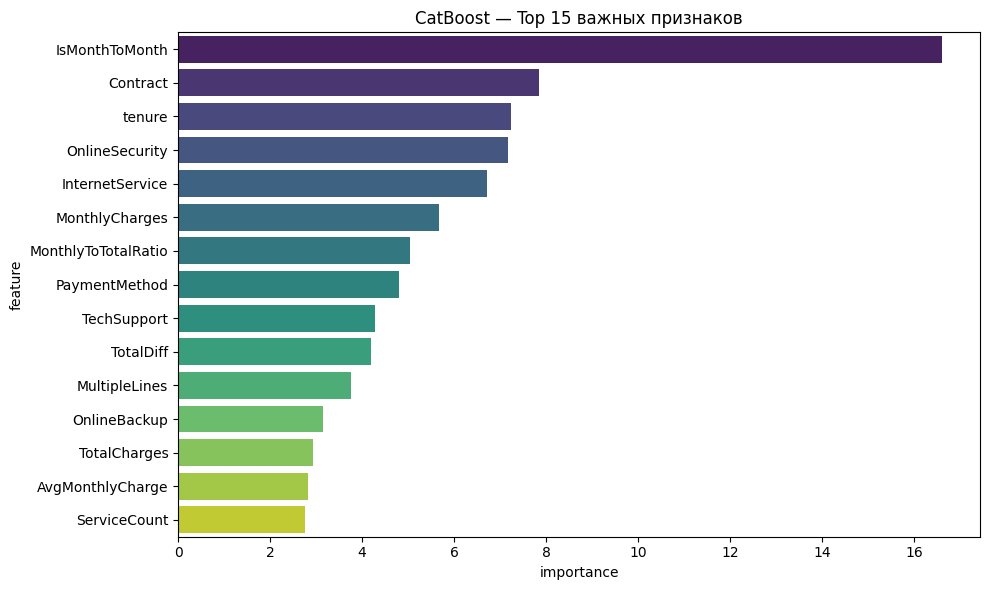

In [14]:
feature_importance = pd.DataFrame({
    'feature': cat_model.feature_names_,
    'importance': cat_model.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('CatBoost — Top 15 важных признаков')
plt.tight_layout()
plt.show()

## 13. Бизнес-порог: максимизация прибыли

Не всегда F1 — то, что реально важно бизнесу. Если удержание клиента
(true positive) стоит компании $20, а потерять клиента без
предупреждения (false negative) — $100, оптимальный порог для F1 и
для прибыли будут разными.

Порог снова подбираем на `val`, а прибыль на этом пороге считаем
на `test` **один раз** — та же логика, что и с F1-порогом выше.

Оптимальный порог по прибыли (найден на val): 0.11
Ожидаемая прибыль на val: $12880


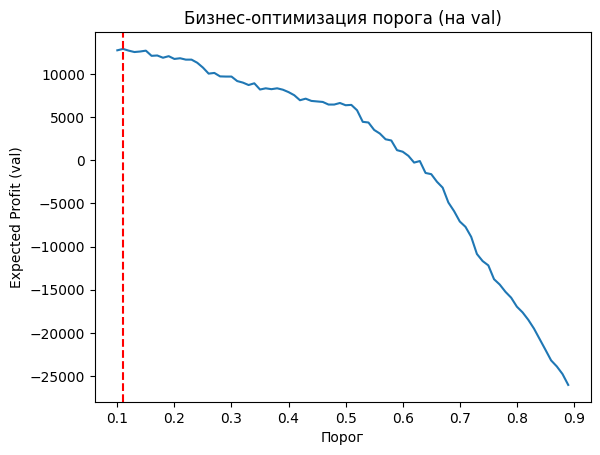


Прибыль на test при этом пороге (честная, one-shot): $15560


In [15]:
def expected_profit(y_true, y_proba, threshold, profit_tp=80, cost_fp=20, cost_fn=100):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp * profit_tp - fp * cost_fp - fn * cost_fn

thresholds_grid = np.arange(0.1, 0.9, 0.01)
profits_val = [expected_profit(y_val, cat_proba_val, t) for t in thresholds_grid]

best_idx = np.argmax(profits_val)
best_thresh_profit = thresholds_grid[best_idx]
print(f"Оптимальный порог по прибыли (найден на val): {best_thresh_profit:.2f}")
print(f"Ожидаемая прибыль на val: ${profits_val[best_idx]}")

plt.plot(thresholds_grid, profits_val)
plt.axvline(best_thresh_profit, color='red', linestyle='--')
plt.xlabel('Порог'); plt.ylabel('Expected Profit (val)'); plt.title('Бизнес-оптимизация порога (на val)')
plt.show()

test_profit = expected_profit(y_test, test_proba, best_thresh_profit)
print(f"\nПрибыль на test при этом пороге (честная, one-shot): ${test_profit}")

## Итоги

- Честная (без утечек) оценка CatBoost на test: **ROC-AUC ≈ 0.84-0.85**,
  что совпадает с CV-оценкой на train (0.847 ± 0.008) — значит, модель
  не переобучена и число на test не случайность.
- LogReg-baseline на тех же признаках даёт сопоставимый результат —
  значит, на этом датасете основной прирост качества даёт не сложность
  модели, а сами признаки (`tenure`, тип контракта, `ServiceCount` и т.п.).
- Дальнейшие шаги, если нужно выжимать ещё: Optuna для тюнинга
  гиперпараметров CatBoost (важно — objective должен оптимизироваться
  по CV на train, не по test), полноценный стекинг с LightGBM/XGBoost
  (потребует OneHot-препроцессинга для них отдельно от CatBoost),
  калибровка вероятностей (`CalibratedClassifierCV`) — особенно
  актуально, если планируешь использовать `predict_proba` для бизнес-решений.